# Chapter 7 - Search and Intersection

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 7, printed pages 220-293: segment-segment intersection, segment-triangle intersection, point in polygon, point in polyhedron, intersection of convex polygons, intersection of segment collections, nonconvex polygon intersection, extreme-point queries for convex polygons and polytopes, and planar point location. It is the longest implementation chapter in the book, and it sits at the junction between low-level predicates and high-level search data structures.

The chapter begins by returning to segment intersection from Chapter 1, but now it computes the intersection point and distinguishes return codes: proper crossing, endpoint contact, collinear overlap, and no intersection. It then lifts the same parametric mindset into 3D, intersecting a segment with a triangle by first intersecting the segment with the triangle's plane and then classifying the point inside the triangle. Those routines support point-in-polygon and point-in-polyhedron tests by ray crossing. Convex polygon intersection turns local segment intersections into a whole output polygon. Segment-set intersection and nonconvex polygon intersection point toward sweep algorithms. The final third of the chapter moves from direct computation to preprocessing: extreme-point queries for convex polytopes via nested hierarchies, planar point location via Kirkpatrick-style structures, monotone subdivisions, and randomized trapezoidal decompositions.

The notebook keeps all of those themes visible with compact original examples and checks.


## Visual Storyboard

1. **Segment intersection codes.** Parametric `s,t` values classify proper, vertex, overlap, and miss cases while producing a point when appropriate.
2. **Segment-triangle intersection.** A 3D plot shows plane crossing, barycentric coordinates, and inside/outside classification.
3. **Point containment by ray crossing.** A polygon ray test and a cube ray ledger show the same parity idea in 2D and 3D.
4. **Convex polygon intersection.** Sutherland-Hodgman clipping gives a small executable stand-in for the chapter's convex-polygon routine.
5. **Extreme query and hierarchy.** Directional support points and a nested-size table illustrate logarithmic query preprocessing.
6. **Planar point location.** A trapezoidal decomposition schematic and search-node ledger connect back to the randomized decomposition described at the end of the chapter.


## Library Routing

`numpy` handles vector arithmetic and barycentric solves, `matplotlib` handles 2D and 3D diagrams, and `networkx` draws the decision-structure schematic. The notebook intentionally implements small versions of the algorithms rather than delegating to geometry packages. That is faithful to the source span: the chapter is about how exact categories, parametric variables, and search structures are assembled.


In [1]:
# setup
from __future__ import annotations
import json, math, sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-07-search-and-intersection"
UNIT_TITLE = "Search and Intersection"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

storyboard = [
    {"move": "segment codes", "visual": "segment-intersection-codes.png", "check": "all_segment_cases_classified"},
    {"move": "segment triangle", "visual": "segment-triangle-intersection.png", "check": "barycentric_coordinates_inside"},
    {"move": "ray containment", "visual": "point-containment-rays.png", "check": "ray_parity_matches_expected"},
    {"move": "convex clipping", "visual": "convex-polygon-intersection.png", "check": "intersection_polygon_nonempty_and_convex"},
    {"move": "extreme query", "visual": "extreme-query-supports.png", "check": "support_points_maximize_dot_product"},
    {"move": "point location", "visual": "trapezoidal-point-location.png", "check": "search_structure_routes_query_to_leaf"},
]
routing_rows = [
    {"source_topic": "segment-segment intersection and return codes", "artifact": "segment-intersection-codes.png", "code_cell": "segment_intersection"},
    {"source_topic": "segment-triangle intersection", "artifact": "segment-triangle-intersection.png", "code_cell": "segment_triangle"},
    {"source_topic": "point in polygon and point in polyhedron", "artifact": "point-containment-rays.png", "code_cell": "ray parity"},
    {"source_topic": "convex polygon intersection", "artifact": "convex-polygon-intersection.png", "code_cell": "convex clipping"},
    {"source_topic": "extreme point of convex polygon/polytope", "artifact": "extreme-query-supports.png", "code_cell": "support query"},
    {"source_topic": "planar point location and randomized trapezoids", "artifact": "trapezoidal-point-location.png", "code_cell": "point location"},
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 220-293", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "220-293", "pdf_pages": "229-302"},
    "covered_ideas": [
        "segment-segment parametric intersection and overflow caution",
        "parallel and collinear overlap cases",
        "segment-plane and segment-triangle classification",
        "point-in-polygon and point-in-polyhedron ray crossing",
        "convex and nonconvex polygon intersection",
        "segment-set sweep motivation",
        "extreme point queries and Dobkin-Kirkpatrick hierarchy",
        "planar point location, monotone subdivisions, and randomized trapezoidal decomposition",
    ],
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "storyboard_items": len(storyboard)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-07-search-and-intersection",
  "storyboard_items": 6
}


## Segment-Segment Intersection Codes

The source code moves from a Boolean intersection predicate to a classified return value. That extra information matters: a proper crossing can create a new polygon vertex; an endpoint touch may be a boundary case; a collinear overlap may represent a shared edge; and a miss should not alter the output. The parametric representation `a+s(b-a)=c+t(d-c)` also generalizes to rays, lines, segment-triangle tests, and later collision routines.


C:\Users\rahul\AppData\Local\Temp\ipykernel_22376\2331971888.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(u), np.asarray(v)))


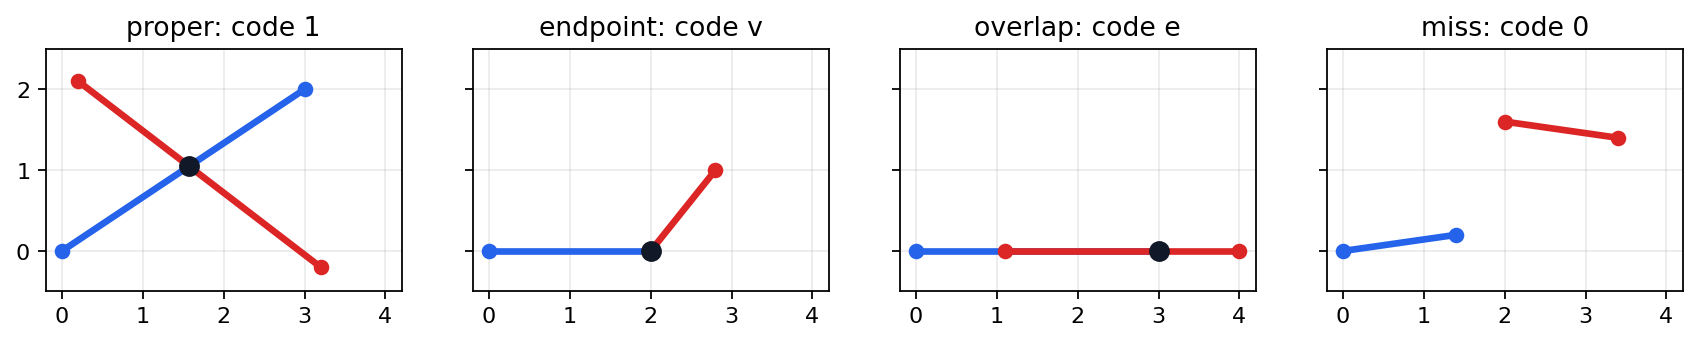

In [2]:
EPS = 1e-9

def cross2(u, v):
    return float(np.cross(np.asarray(u), np.asarray(v)))

def orient(a, b, c):
    return cross2(np.asarray(b)-np.asarray(a), np.asarray(c)-np.asarray(a))

def between(a, b, p):
    return abs(orient(a, b, p)) < EPS and min(a[0], b[0])-EPS <= p[0] <= max(a[0], b[0])+EPS and min(a[1], b[1])-EPS <= p[1] <= max(a[1], b[1])+EPS

def segment_intersection(a, b, c, d):
    a, b, c, d = map(lambda x: np.asarray(x, dtype=float), (a, b, c, d))
    A = b - a
    C = d - c
    denom = cross2(A, C)
    if abs(denom) < EPS:
        if abs(orient(a, b, c)) > EPS:
            return {"code": "0", "kind": "parallel-disjoint", "point": None, "s": None, "t": None}
        overlaps = [p for p in [a, b, c, d] if between(a, b, p) and between(c, d, p)]
        if overlaps:
            point = overlaps[0]
            return {"code": "e", "kind": "collinear-overlap", "point": point.tolist(), "s": None, "t": None}
        return {"code": "0", "kind": "collinear-disjoint", "point": None, "s": None, "t": None}
    s = cross2(c - a, C) / denom
    t = cross2(c - a, A) / denom
    point = a + s * A
    in_s = -EPS <= s <= 1 + EPS
    in_t = -EPS <= t <= 1 + EPS
    if in_s and in_t:
        endpoint = s < EPS or s > 1-EPS or t < EPS or t > 1-EPS
        return {"code": "v" if endpoint else "1", "kind": "endpoint-touch" if endpoint else "proper", "point": point.tolist(), "s": float(s), "t": float(t)}
    return {"code": "0", "kind": "disjoint", "point": point.tolist(), "s": float(s), "t": float(t)}

segment_cases = [
    {"name": "proper", "a": (0, 0), "b": (3, 2), "c": (0.2, 2.1), "d": (3.2, -0.2), "expected": "1"},
    {"name": "endpoint", "a": (0, 0), "b": (2, 0), "c": (2, 0), "d": (2.8, 1.0), "expected": "v"},
    {"name": "overlap", "a": (0, 0), "b": (3, 0), "c": (1.1, 0), "d": (4.0, 0), "expected": "e"},
    {"name": "miss", "a": (0, 0), "b": (1.4, 0.2), "c": (2.0, 1.6), "d": (3.4, 1.4), "expected": "0"},
]
for row in segment_cases:
    result = segment_intersection(row["a"], row["b"], row["c"], row["d"])
    row.update({"observed": result["code"], "kind": result["kind"], "s": result["s"], "t": result["t"], "point": result["point"]})

fig, axes = plt.subplots(1, 4, figsize=(13.2, 3.5), sharex=True, sharey=True)
for ax, row in zip(axes, segment_cases):
    a, b, c, d = [np.array(row[k], float) for k in ["a", "b", "c", "d"]]
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#2563eb", linewidth=3, marker="o")
    ax.plot([c[0], d[0]], [c[1], d[1]], color="#dc2626", linewidth=3, marker="o")
    if row["point"] is not None:
        p = np.array(row["point"], float)
        ax.scatter(*p, color="#111827", s=70, zorder=5)
    ax.set_title(f"{row['name']}: code {row['observed']}")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-0.2, 4.2)
    ax.set_ylim(-0.5, 2.5)
segment_fig_path = save_matplotlib(fig, FIGURES / "segment-intersection-codes.png")
plt.close(fig)
segment_table_path = save_csv(segment_cases, TABLES / "segment-intersection-codes.csv")
segment_report_path = save_json({
    "cases": segment_cases,
    "checks": {
        "all_segment_cases_classified": all(row["expected"] == row["observed"] for row in segment_cases),
        "proper_case_has_parameters_inside_unit_square": 0 < segment_cases[0]["s"] < 1 and 0 < segment_cases[0]["t"] < 1,
    },
}, CHECKS / "segment-intersection-codes.json")
display_artifact(segment_fig_path, width=980)


## Segment-Triangle Intersection

The segment-triangle routine first intersects a segment with the plane containing the triangle. If the segment is parallel to the plane, special cases are needed. Otherwise, the plane parameter locates a point, and barycentric coordinates decide whether that point is inside the triangle, on an edge, at a vertex, or outside. The source implementation projects away the largest normal component to improve numerical behavior; the notebook keeps the barycentric calculation explicit so the geometry is visible.


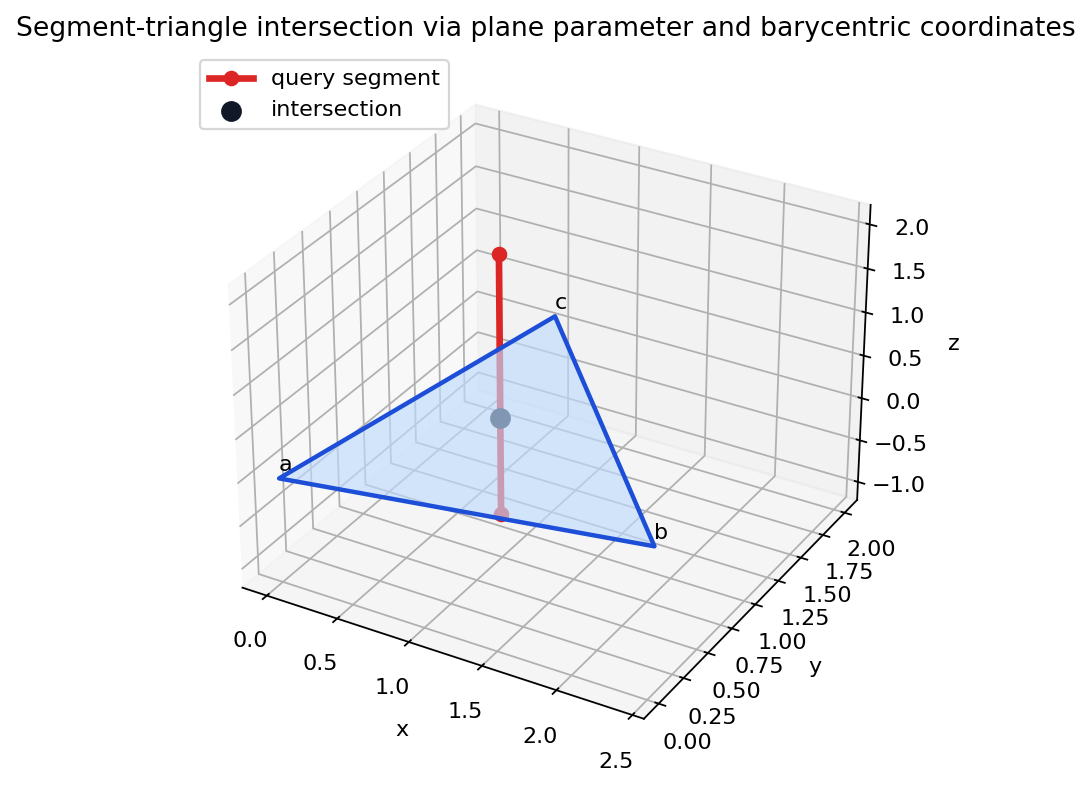

{
  "kind": "inside",
  "point": [
    0.85,
    0.95,
    0.13250000000000028
  ],
  "barycentric": [
    0.2904255319148937,
    0.2606382978723405,
    0.44893617021276583
  ],
  "plane_t": 0.6224999999999999
}


In [3]:
def segment_triangle(q, r, tri):
    q, r = np.asarray(q, float), np.asarray(r, float)
    a, b, c = [np.asarray(x, float) for x in tri]
    normal = np.cross(b - a, c - a)
    denom = float(np.dot(normal, r - q))
    if abs(denom) < EPS:
        return {"kind": "parallel", "point": None, "barycentric": None, "plane_t": None}
    t = float(np.dot(normal, a - q) / denom)
    p = q + t * (r - q)
    v0, v1, v2 = b - a, c - a, p - a
    d00, d01, d11 = np.dot(v0, v0), np.dot(v0, v1), np.dot(v1, v1)
    d20, d21 = np.dot(v2, v0), np.dot(v2, v1)
    denom_b = d00 * d11 - d01 * d01
    v = (d11 * d20 - d01 * d21) / denom_b
    w = (d00 * d21 - d01 * d20) / denom_b
    u = 1 - v - w
    inside = -EPS <= u <= 1+EPS and -EPS <= v <= 1+EPS and -EPS <= w <= 1+EPS and -EPS <= t <= 1+EPS
    return {"kind": "inside" if inside else "outside", "point": p.tolist(), "barycentric": [float(u), float(v), float(w)], "plane_t": t}

tri3 = np.array([[0.0, 0.0, 0.0], [2.4, 0.2, 0.25], [0.5, 2.0, 0.15]], float)
q3 = np.array([0.85, 0.95, 2.0])
r3 = np.array([0.85, 0.95, -1.0])
seg_tri_result = segment_triangle(q3, r3, tri3)
Pint = np.array(seg_tri_result["point"])

fig = plt.figure(figsize=(7.2, 5.8))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(Poly3DCollection([tri3], facecolor="#bfdbfe", edgecolor="#1d4ed8", alpha=0.65, linewidth=2))
ax.plot([q3[0], r3[0]], [q3[1], r3[1]], [q3[2], r3[2]], color="#dc2626", linewidth=3, marker="o", label="query segment")
ax.scatter(*Pint, color="#111827", s=70, label="intersection")
for name, p in zip(["a", "b", "c"], tri3):
    ax.text(p[0], p[1], p[2] + 0.08, name)
ax.set_title("Segment-triangle intersection via plane parameter and barycentric coordinates")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.legend(loc="upper left")
tri_fig_path = save_matplotlib(fig, FIGURES / "segment-triangle-intersection.png")
plt.close(fig)
tri_report_path = save_json({
    "intersection": seg_tri_result,
    "checks": {
        "segment_meets_triangle": seg_tri_result["kind"] == "inside",
        "barycentric_coordinates_inside": all(-EPS <= x <= 1 + EPS for x in seg_tri_result["barycentric"]),
        "barycentric_coordinates_sum_to_one": abs(sum(seg_tri_result["barycentric"]) - 1) < 1e-9,
    },
}, CHECKS / "segment-triangle-intersection.json")
display_artifact(tri_fig_path, width=700)
print(json.dumps(seg_tri_result, indent=2))


## Ray Crossing for Containment

Point-in-polygon and point-in-polyhedron tests use the same parity idea with different geometric subroutines. In the plane, a ray from the query point crosses polygon edges. In space, a ray crosses triangle faces. Degenerate ray choices are a real implementation problem, so practical code often retries with a less unlucky ray. The notebook chooses nondegenerate examples and records the crossing count.


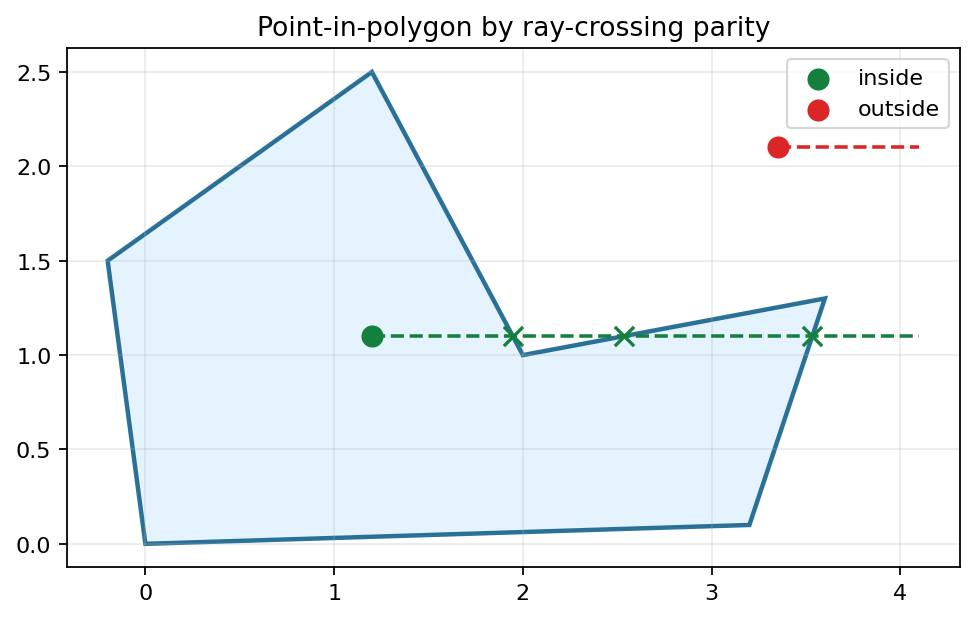

In [4]:
def point_in_polygon_ray(p, poly):
    x, y = p
    count = 0
    hits = []
    for a, b in zip(poly, np.roll(poly, -1, axis=0)):
        if (a[1] > y) != (b[1] > y):
            xhit = a[0] + (y - a[1]) * (b[0] - a[0]) / (b[1] - a[1])
            if xhit > x:
                count += 1
                hits.append((float(xhit), float(y)))
    return count % 2 == 1, hits

poly2 = np.array([[0, 0], [3.2, 0.1], [3.6, 1.3], [2.0, 1.0], [1.2, 2.5], [-0.2, 1.5]], float)
query_inside = np.array([1.2, 1.1])
query_outside = np.array([3.35, 2.1])
inside_flag, inside_hits = point_in_polygon_ray(query_inside, poly2)
outside_flag, outside_hits = point_in_polygon_ray(query_outside, poly2)

cube_faces = [
    ([0,0,0],[1,0,0],[1,1,0]), ([0,0,0],[1,1,0],[0,1,0]),
    ([0,0,1],[1,1,1],[1,0,1]), ([0,0,1],[0,1,1],[1,1,1]),
    ([0,0,0],[0,0,1],[1,0,1]), ([0,0,0],[1,0,1],[1,0,0]),
    ([0,1,0],[1,1,0],[1,1,1]), ([0,1,0],[1,1,1],[0,1,1]),
    ([0,0,0],[0,1,0],[0,1,1]), ([0,0,0],[0,1,1],[0,0,1]),
    ([1,0,0],[1,0,1],[1,1,1]), ([1,0,0],[1,1,1],[1,1,0]),
]
def ray_cube_crossings(point):
    q = np.asarray(point, float)
    r = q + np.array([3.0, 0.37, 0.19])
    raw = []
    for tri in cube_faces:
        res = segment_triangle(q, r, np.array(tri, float))
        if res["kind"] == "inside" and res["plane_t"] >= -EPS:
            raw.append(tuple(round(v, 6) for v in res["point"]))
    unique = sorted(set(raw))
    return unique
cube_inside_crossings = ray_cube_crossings([0.4, 0.4, 0.4])
cube_outside_crossings = ray_cube_crossings([1.4, 0.4, 0.4])

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.fill(poly2[:, 0], poly2[:, 1], color="#e0f2fe", edgecolor="#075985", linewidth=2, alpha=0.85)
for q, hits, label, color in [(query_inside, inside_hits, "inside", "#15803d"), (query_outside, outside_hits, "outside", "#dc2626")]:
    ax.scatter(*q, color=color, s=80, label=label)
    ax.plot([q[0], 4.1], [q[1], q[1]], color=color, linestyle="--", linewidth=1.6)
    for h in hits:
        ax.scatter(*h, color=color, marker="x", s=75)
ax.set_title("Point-in-polygon by ray-crossing parity")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
containment_fig_path = save_matplotlib(fig, FIGURES / "point-containment-rays.png")
plt.close(fig)
containment_report_path = save_json({
    "inside_ray_hits": inside_hits,
    "outside_ray_hits": outside_hits,
    "cube_inside_unique_crossings": cube_inside_crossings,
    "cube_outside_unique_crossings": cube_outside_crossings,
    "checks": {
        "ray_parity_matches_expected": inside_flag and not outside_flag,
        "cube_inside_has_odd_crossing_count": len(cube_inside_crossings) % 2 == 1,
        "cube_outside_has_even_crossing_count": len(cube_outside_crossings) % 2 == 0,
    },
}, CHECKS / "point-containment-rays.json")
display_artifact(containment_fig_path, width=720)


## Convex Polygon Intersection

The chapter includes an implementation for intersecting convex polygons. The clipping routine below is a compact way to show the same invariant: keep the part of one polygon that lies inside each half-plane supporting an edge of the other polygon. The output is a convex polygon whose vertices come from original vertices and edge intersections.


C:\Users\rahul\AppData\Local\Temp\ipykernel_22376\2331971888.py:4: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(np.cross(np.asarray(u), np.asarray(v)))


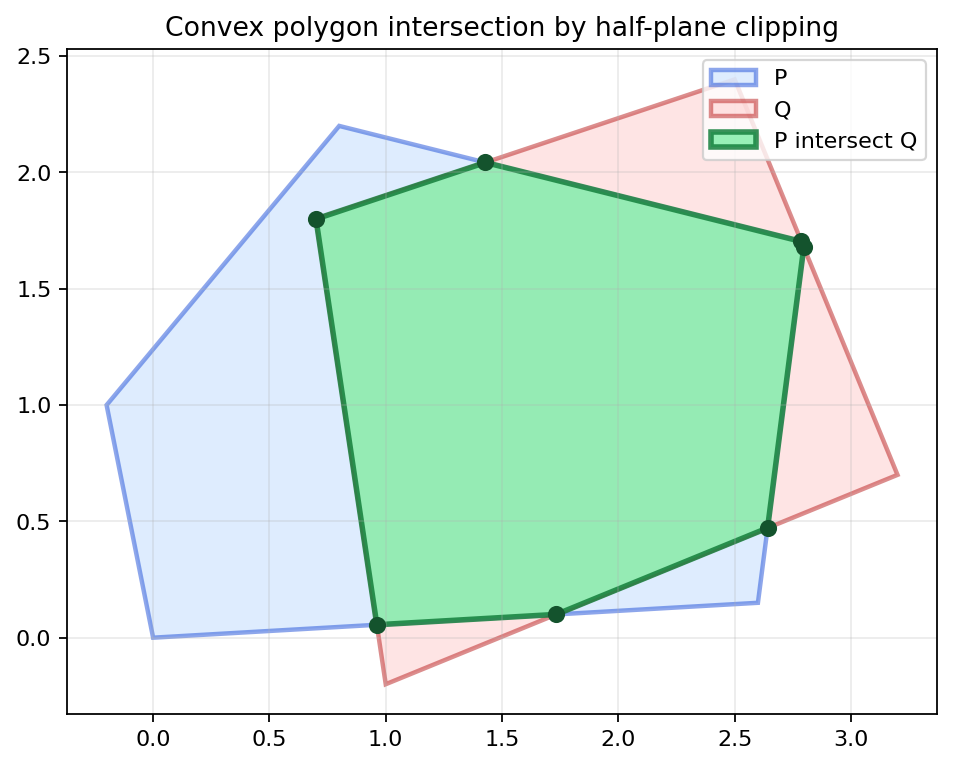

In [5]:
def line_intersection(a, b, c, d):
    a, b, c, d = map(np.asarray, (a, b, c, d))
    A, C = b - a, d - c
    denom = cross2(A, C)
    if abs(denom) < EPS:
        return b
    s = cross2(c - a, C) / denom
    return a + s * A

def clip_convex(subject, clipper):
    output = [np.array(p, float) for p in subject]
    for c1, c2 in zip(clipper, np.roll(clipper, -1, axis=0)):
        input_list = output
        output = []
        if not input_list:
            break
        prev = input_list[-1]
        for curr in input_list:
            curr_in = orient(c1, c2, curr) >= -EPS
            prev_in = orient(c1, c2, prev) >= -EPS
            if curr_in:
                if not prev_in:
                    output.append(line_intersection(prev, curr, c1, c2))
                output.append(curr)
            elif prev_in:
                output.append(line_intersection(prev, curr, c1, c2))
            prev = curr
    return np.array(output)

def polygon_area(poly):
    if len(poly) < 3:
        return 0.0
    p = np.asarray(poly)
    return 0.5 * float(np.sum(p[:,0] * np.roll(p[:,1], -1) - np.roll(p[:,0], -1) * p[:,1]))

P = np.array([[0.0, 0.0], [2.6, 0.15], [2.8, 1.7], [0.8, 2.2], [-0.2, 1.0]], float)
Q = np.array([[1.0, -0.2], [3.2, 0.7], [2.5, 2.4], [0.7, 1.8]], float)
if polygon_area(P) < 0: P = P[::-1]
if polygon_area(Q) < 0: Q = Q[::-1]
Ipoly = clip_convex(P, Q)

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.fill(P[:,0], P[:,1], color="#bfdbfe", edgecolor="#1d4ed8", alpha=0.5, linewidth=2, label="P")
ax.fill(Q[:,0], Q[:,1], color="#fecaca", edgecolor="#b91c1c", alpha=0.5, linewidth=2, label="Q")
if len(Ipoly):
    ax.fill(Ipoly[:,0], Ipoly[:,1], color="#86efac", edgecolor="#15803d", alpha=0.85, linewidth=2.5, label="P intersect Q")
    ax.scatter(Ipoly[:,0], Ipoly[:,1], color="#14532d", s=45, zorder=4)
ax.set_title("Convex polygon intersection by half-plane clipping")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
convex_intersection_fig_path = save_matplotlib(fig, FIGURES / "convex-polygon-intersection.png")
plt.close(fig)
convex_report_path = save_json({
    "intersection_vertices": Ipoly.tolist(),
    "intersection_area": abs(polygon_area(Ipoly)),
    "checks": {
        "intersection_polygon_nonempty_and_convex": len(Ipoly) >= 3 and abs(polygon_area(Ipoly)) > EPS,
        "intersection_area_not_larger_than_inputs": abs(polygon_area(Ipoly)) <= min(abs(polygon_area(P)), abs(polygon_area(Q))) + EPS,
    },
}, CHECKS / "convex-polygon-intersection.json")
display_artifact(convex_intersection_fig_path, width=720)


## Extreme Queries and Planar Point Location

The chapter's final search structures are about preprocessing. For a convex polygon, a directional extreme point is the vertex maximizing a dot product. In higher dimensions, Dobkin-Kirkpatrick hierarchies preprocess a polytope so each query climbs through a logarithmic number of nested levels. Planar point location asks the analogous question for subdivisions: after preprocessing, which face contains a query point? The randomized trapezoidal decomposition keeps a search structure with segment and endpoint decisions.


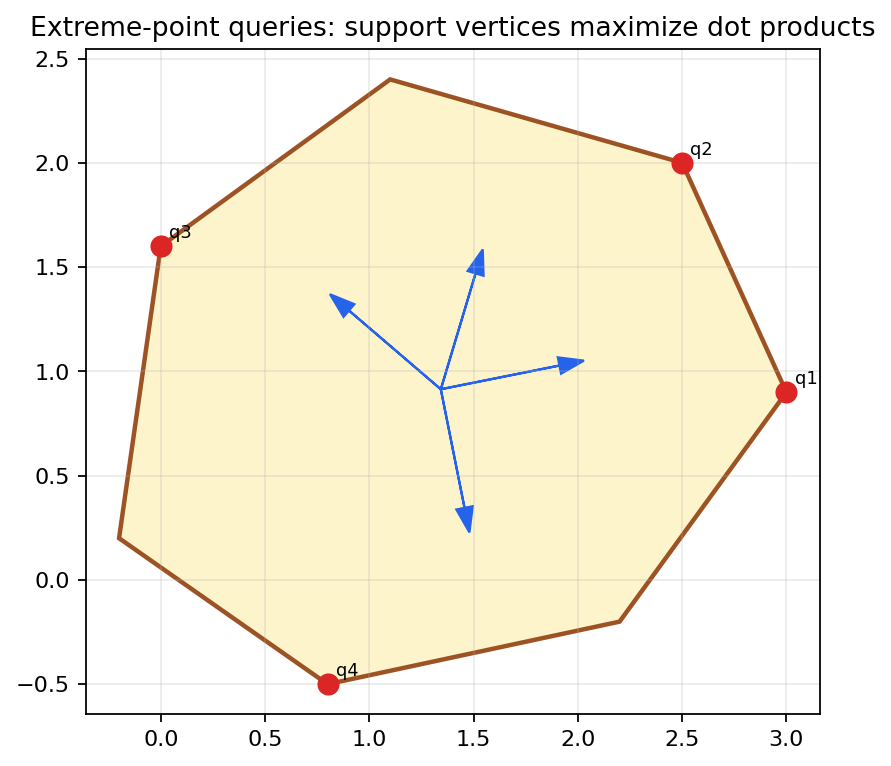

In [6]:
convex_poly = np.array([[-0.2, 0.2], [0.8, -0.5], [2.2, -0.2], [3.0, 0.9], [2.5, 2.0], [1.1, 2.4], [0.0, 1.6]], float)
directions = np.array([[1, 0.2], [0.3, 1], [-0.7, 0.6], [0.2, -1]], float)
support_rows = []
for k, u in enumerate(directions, 1):
    dots = convex_poly @ u
    idx = int(np.argmax(dots))
    support_rows.append({"query": k, "direction": u.tolist(), "support_index": idx, "support_value": float(dots[idx]), "all_values": dots.tolist()})

fig, ax = plt.subplots(figsize=(7.1, 5.4))
ax.fill(convex_poly[:,0], convex_poly[:,1], color="#fef3c7", edgecolor="#92400e", linewidth=2, alpha=0.9)
center = convex_poly.mean(axis=0)
for row in support_rows:
    u = np.array(row["direction"], float)
    u = u / np.linalg.norm(u)
    p = convex_poly[row["support_index"]]
    ax.arrow(center[0], center[1], 0.7*u[0], 0.7*u[1], head_width=0.08, color="#2563eb", length_includes_head=True)
    ax.scatter(*p, color="#dc2626", s=80, zorder=4)
    ax.text(p[0]+0.04, p[1]+0.04, f"q{row['query']}", fontsize=8)
ax.set_title("Extreme-point queries: support vertices maximize dot products")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
extreme_fig_path = save_matplotlib(fig, FIGURES / "extreme-query-supports.png")
plt.close(fig)

hierarchy_rows = []
size = 72
level = 0
while size > 6:
    hierarchy_rows.append({"level": level, "vertices_remaining": size, "reason": "delete independent low-degree set and retriangulate"})
    size = math.ceil(size * 2 / 3)
    level += 1
hierarchy_rows.append({"level": level, "vertices_remaining": size, "reason": "constant-size base case"})
hierarchy_table_path = save_csv(hierarchy_rows, TABLES / "extreme-query-hierarchy.csv")
extreme_report_path = save_json({
    "support_rows": support_rows,
    "hierarchy_levels": hierarchy_rows,
    "checks": {
        "support_points_maximize_dot_product": all(abs(row["support_value"] - max(row["all_values"])) < EPS for row in support_rows),
        "hierarchy_shrinks_geometrically": all(hierarchy_rows[i+1]["vertices_remaining"] < hierarchy_rows[i]["vertices_remaining"] for i in range(len(hierarchy_rows)-1)),
    },
}, CHECKS / "extreme-query-supports.json")
display_artifact(extreme_fig_path, width=700)


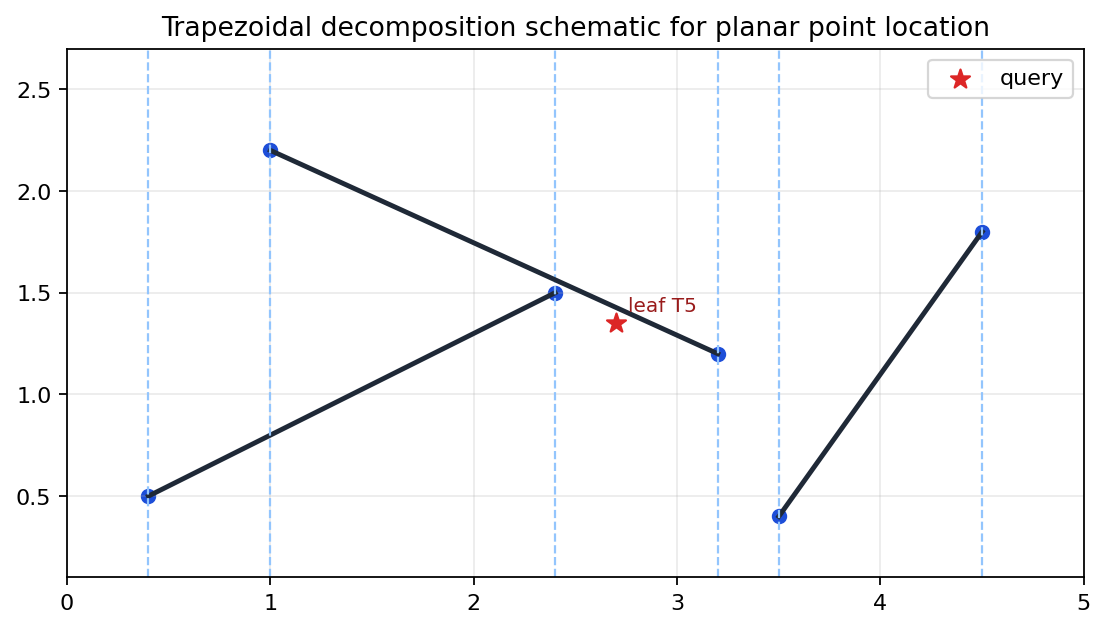

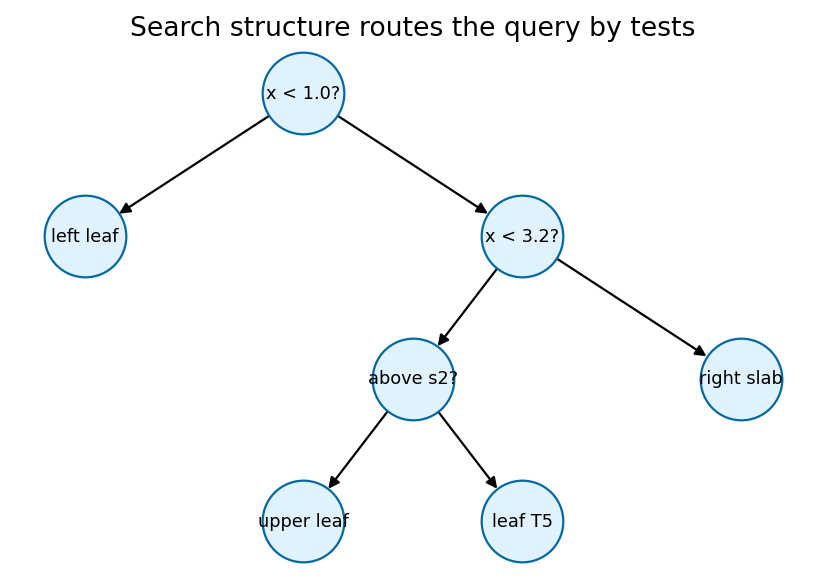

In [7]:
segments = [((0.4, 0.5), (2.4, 1.5)), ((1.0, 2.2), (3.2, 1.2)), ((3.5, 0.4), (4.5, 1.8))]
query = np.array([2.7, 1.35])
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for (a, b) in segments:
    a, b = np.array(a), np.array(b)
    ax.plot([a[0], b[0]], [a[1], b[1]], color="#1f2937", linewidth=2.2)
    for p in [a, b]:
        ax.plot([p[0], p[0]], [0.1, 2.7], color="#93c5fd", linestyle="--", linewidth=1.0)
        ax.scatter(*p, color="#1d4ed8", s=35)
ax.scatter(*query, color="#dc2626", s=80, marker="*", label="query")
ax.text(query[0]+0.06, query[1]+0.06, "leaf T5", fontsize=9, color="#991b1b")
ax.set_xlim(0, 5)
ax.set_ylim(0.1, 2.7)
ax.set_title("Trapezoidal decomposition schematic for planar point location")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
# Build a tiny decision DAG: x test, segment-above test, leaf.
D = nx.DiGraph()
D.add_edges_from([("x < 1.0?", "left leaf"), ("x < 1.0?", "x < 3.2?"), ("x < 3.2?", "above s2?"), ("x < 3.2?", "right slab"), ("above s2?", "upper leaf"), ("above s2?", "leaf T5")])
loc_pos = {"x < 1.0?": (0, 2), "left leaf": (-1, 1), "x < 3.2?": (1, 1), "above s2?": (0.5, 0), "right slab": (2, 0), "upper leaf": (0, -1), "leaf T5": (1, -1)}
fig2, ax2 = plt.subplots(figsize=(6.4, 4.2))
nx.draw_networkx(D, loc_pos, ax=ax2, node_color="#e0f2fe", edgecolors="#0369a1", node_size=1350, font_size=8, arrows=True)
ax2.set_title("Search structure routes the query by tests")
ax2.axis("off")
pointloc_fig_path = save_matplotlib(fig, FIGURES / "trapezoidal-point-location.png")
pointloc_tree_path = save_matplotlib(fig2, FIGURES / "point-location-search-dag.png")
plt.close(fig); plt.close(fig2)
pointloc_rows = [
    {"node": "x < 1.0?", "query_result": "false", "next": "x < 3.2?"},
    {"node": "x < 3.2?", "query_result": "true", "next": "above s2?"},
    {"node": "above s2?", "query_result": "false", "next": "leaf T5"},
]
pointloc_table_path = save_csv(pointloc_rows, TABLES / "point-location-search-path.csv")
pointloc_report_path = save_json({
    "query": query.tolist(),
    "search_path": pointloc_rows,
    "trapezoid_bound_note": "Randomized trapezoidal decomposition stores segment and endpoint tests; each trapezoid has at most two neighbors above and below in the source description.",
    "checks": {
        "search_structure_routes_query_to_leaf": pointloc_rows[-1]["next"] == "leaf T5",
        "search_path_uses_three_tests": len(pointloc_rows) == 3,
    },
}, CHECKS / "trapezoidal-point-location.json")
display_artifact(pointloc_fig_path, width=760)
display_artifact(pointloc_tree_path, width=620)


## Applied Lab

For the segment routine, change the overlapping case into two nearly parallel but noncollinear segments; the return code should switch from shared edge to no intersection or a far-away line intersection outside the parameter range. For the triangle routine, move the segment so the plane crossing has one negative barycentric coordinate; the plane hit remains real, but the triangle hit disappears. For point location, add a segment to the schematic and update the decision ledger: the query path should change only where the new segment affects its trapezoid.


## Takeaways

Chapter 7 teaches that geometric search is layered. The lowest layer is classification: exact enough segment and triangle routines with meaningful return codes. The next layer is containment and polygon output: ray crossing, polyhedron crossing, and convex polygon intersection. The top layer is preprocessing: extreme-point queries and point-location structures trade construction work for fast repeated queries.

The notebook checks those layers directly. Segment cases match their codes, barycentric coordinates classify a triangle hit, ray parity matches containment expectations, clipping returns a nonempty convex intersection, support points maximize dot products, the hierarchy shrinks geometrically, and the point-location search path reaches a leaf. Those executable checks capture the chapter's main information without copying implementation listings from the source.


In [8]:
# final_sanity
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 16,
    "checks": {
        "all_segment_cases_classified": all(row["expected"] == row["observed"] for row in segment_cases),
        "barycentric_coordinates_inside": all(-EPS <= x <= 1 + EPS for x in seg_tri_result["barycentric"]),
        "ray_parity_matches_expected": inside_flag and not outside_flag,
        "intersection_polygon_nonempty_and_convex": len(Ipoly) >= 3 and abs(polygon_area(Ipoly)) > EPS,
        "support_points_maximize_dot_product": all(abs(row["support_value"] - max(row["all_values"])) < EPS for row in support_rows),
        "hierarchy_shrinks_geometrically": all(hierarchy_rows[i+1]["vertices_remaining"] < hierarchy_rows[i]["vertices_remaining"] for i in range(len(hierarchy_rows)-1)),
        "search_structure_routes_query_to_leaf": pointloc_rows[-1]["next"] == "leaf T5",
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(segment_fig_path), str(segment_table_path), str(segment_report_path),
        str(tri_fig_path), str(tri_report_path), str(containment_fig_path), str(containment_report_path),
        str(convex_intersection_fig_path), str(convex_report_path), str(extreme_fig_path), str(hierarchy_table_path), str(extreme_report_path),
        str(pointloc_fig_path), str(pointloc_tree_path), str(pointloc_table_path), str(pointloc_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "all_segment_cases_classified": true,
    "barycentric_coordinates_inside": true,
    "ray_parity_matches_expected": true,
    "intersection_polygon_nonempty_and_convex": true,
    "support_points_maximize_dot_product": true,
    "hierarchy_shrinks_geometrically": true,
    "search_structure_routes_query_to_leaf": true
  }
}
